<a href="https://colab.research.google.com/github/Fotimai-Zahro/Titanic-Survival-Prediction/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Downloading the Titanic dataset
!wget https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv -O train.csv

print("Dataset downloaded successfully!")

--2026-03-14 08:54:24--  https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv
Resolving web.stanford.edu (web.stanford.edu)... 171.67.215.200, 2607:f6d0:0:925a::ab43:d7c8
Connecting to web.stanford.edu (web.stanford.edu)|171.67.215.200|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44225 (43K) [text/csv]
Saving to: ‘train.csv’

train.csv           100%[===================>]  43.19K  --.-KB/s    in 0.1s    

2026-03-14 08:54:24 (404 KB/s) - ‘train.csv’ saved [44225/44225]

Dataset downloaded successfully!


In [2]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Style for Visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Loading the data
train_df = pd.read_csv('train.csv')

print(f"Dataset loaded! Shape: {train_df.shape}")
print("\nFirst 5 rows:")
train_df.head()

Dataset loaded! Shape: (887, 8)

First 5 rows:


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [4]:
# Dataset information
print("=== Dataset Information ===")
print(train_df.info())

print("\n=== Statistical summary ===")
print(train_df.describe())

print("\n=== Missing values ===")
missing = train_df.isnull().sum()
print(missing[missing > 0])

=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB
None

=== Statistical summary ===
         Survived      Pclass         Age  Siblings/Spouses Aboard  \
count  887.000000  887.000000  887.000000               887.000000   
mean     0.385569    2.305524   29.471443                 0.525366   
std      0.487004    

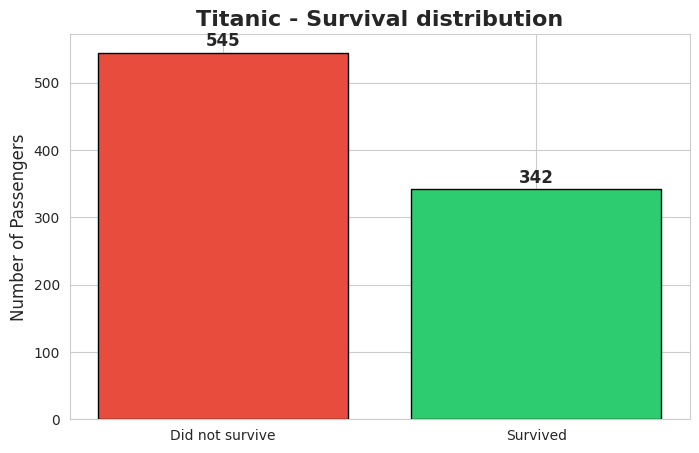


Overall survival rate: 38.56%


In [5]:
# Survival distribution
plt.figure(figsize=(8, 5))
survival_counts = train_df['Survived'].value_counts()
plt.bar(['Did not survive', 'Survived'], survival_counts.values,
        color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Titanic - Survival distribution', fontsize=16, fontweight='bold')
plt.ylabel('Number of Passengers', fontsize=12)

for i, v in enumerate(survival_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontsize=12, fontweight='bold')

plt.show()

print(f"\nOverall survival rate: {train_df['Survived'].mean()*100:.2f}%")

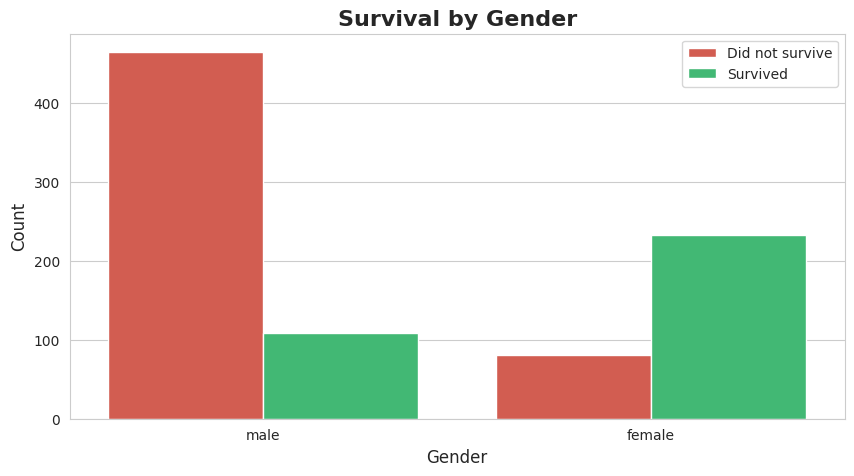


=== Survival Rate by Gender ===
Female: 74.20%
Male: 19.02%


In [6]:
# Survival by Gender
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Sex', hue='Survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Did not survive', 'Survived'], loc='upper right')
plt.show()

# Survival rate by Gender
gender_survival = train_df.groupby('Sex')['Survived'].mean()
print("\n=== Survival Rate by Gender ===")
for gender, rate in gender_survival.items():
    print(f"{gender.capitalize()}: {rate*100:.2f}%")

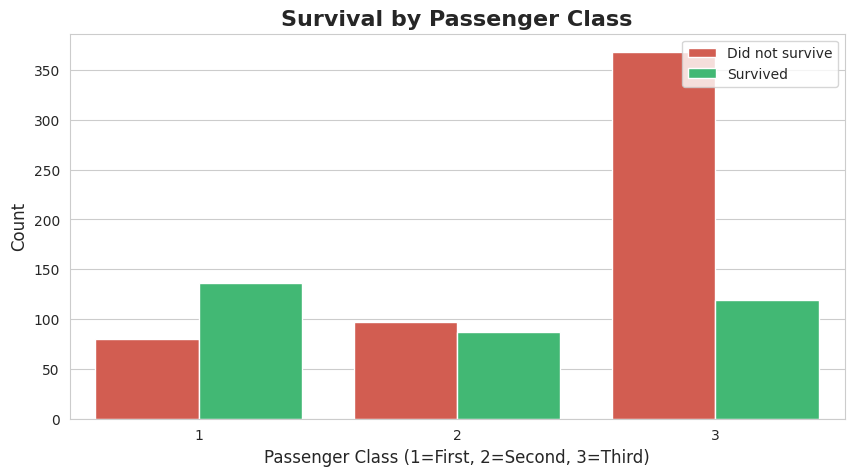


=== Survival Rate by Class ===
Class 1: 62.96%
Class 2: 47.28%
Class 3: 24.44%


In [7]:
# Survival by Passenger Class
plt.figure(figsize=(10, 5))
sns.countplot(data=train_df, x='Pclass', hue='Survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Passenger Class', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(['Did not survive', 'Survived'], loc='upper right')
plt.show()

# Survival rate by Class
class_survival = train_df.groupby('Pclass')['Survived'].mean()
print("\n=== Survival Rate by Class ===")
for pclass, rate in class_survival.items():
    print(f"Class {pclass}: {rate*100:.2f}%")

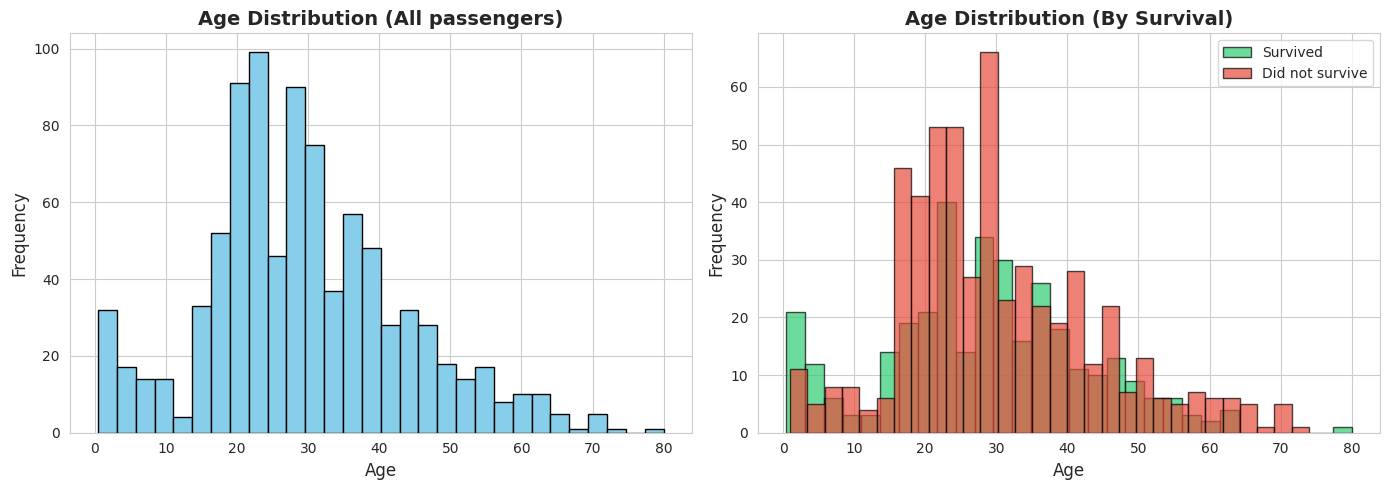

In [8]:
# Age Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All passengers
axes[0].hist(train_df['Age'].dropna(), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Age Distribution (All passengers)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# By survival
train_df[train_df['Survived']==1]['Age'].hist(bins=30, color='#2ecc71',
                                                alpha=0.7, label='Survived',
                                                edgecolor='black', ax=axes[1])
train_df[train_df['Survived']==0]['Age'].hist(bins=30, color='#e74c3c',
                                                alpha=0.7, label='Did not survive',
                                                edgecolor='black', ax=axes[1])
axes[1].set_title('Age Distribution (By Survival)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Preparing data for Machine Learning
def preprocess_data(df):
    data = df.copy()

    # Filling missing values
    if 'Age' in data.columns:
        data['Age'].fillna(data['Age'].median(), inplace=True)
    if 'Fare' in data.columns:
        data['Fare'].fillna(data['Fare'].median(), inplace=True)

    # Creating new features (if columns exist)
    if 'SibSp' in data.columns and 'Parch' in data.columns:
        data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
        data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
    else:
        data['FamilySize'] = 1
        data['IsAlone'] = 1

    # Converting categorical data to numeric
    if 'Sex' in data.columns:
        data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

    # Checking available columns
    available_features = []
    possible_features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone']

    for feature in possible_features:
        if feature in data.columns:
            available_features.append(feature)

    print(f"Available columns: {list(data.columns)}")
    print(f"Features being used: {available_features}")

    return data[available_features]

# Data preparation
X = preprocess_data(train_df)
y = train_df['Survived']

print("\n✅ Data prepared!")
print(f"Feature matrix shape: {X.shape}")

Available columns: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare', 'FamilySize', 'IsAlone']
Features being used: ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone']

✅ Data prepared!
Feature matrix shape: (887, 6)


/tmp/ipykernel_283/1422146793.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/tmp/ipykernel_283/1422146793.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [10]:
# Data splitting
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# Logistic Regression model
print("\n" + "="*50)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*50)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_val)
lr_accuracy = accuracy_score(y_val, lr_pred)

print(f"\n✅ Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")

# Decision Tree model
print("\n" + "="*50)
print("MODEL 2: DECISION TREE")
print("="*50)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_val)
dt_accuracy = accuracy_score(y_val, dt_pred)

print(f"\n✅ Decision Tree Accuracy: {dt_accuracy*100:.2f}%")

Training set: 709 samples
Validation set: 178 samples

MODEL 1: LOGISTIC REGRESSION

✅ Logistic Regression Accuracy: 76.40%

MODEL 2: DECISION TREE

✅ Decision Tree Accuracy: 79.78%


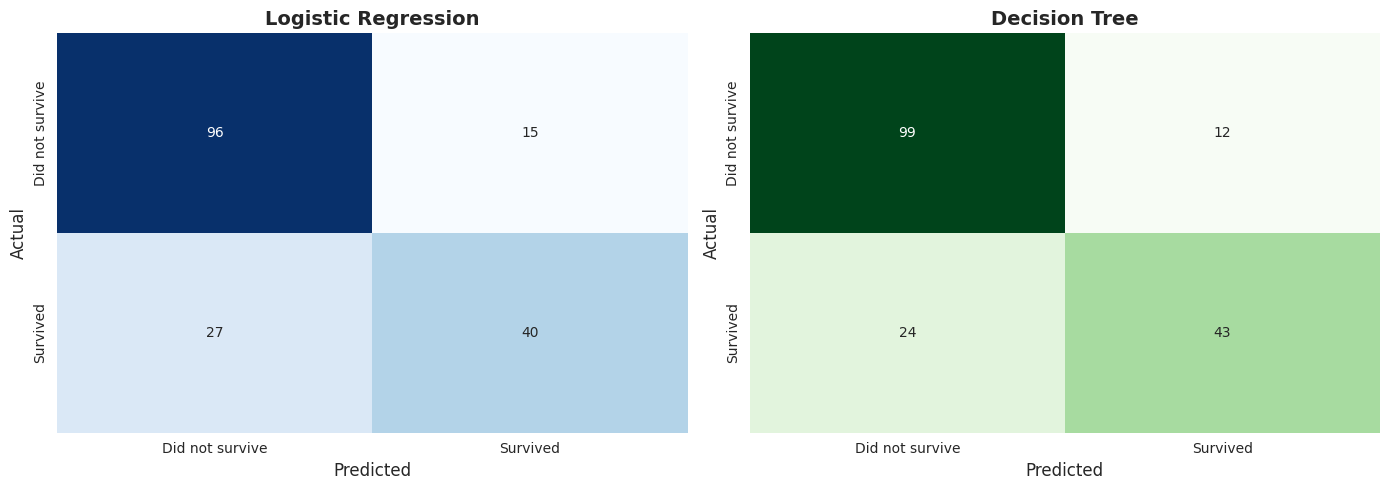

In [11]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_val, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
axes[0].set_title('Logistic Regression', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Decision Tree
cm_dt = confusion_matrix(y_val, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
axes[1].set_title('Decision Tree', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()


MODEL COMPARISON
              Model  Accuracy (%)
Logistic Regression     76.404494
      Decision Tree     79.775281


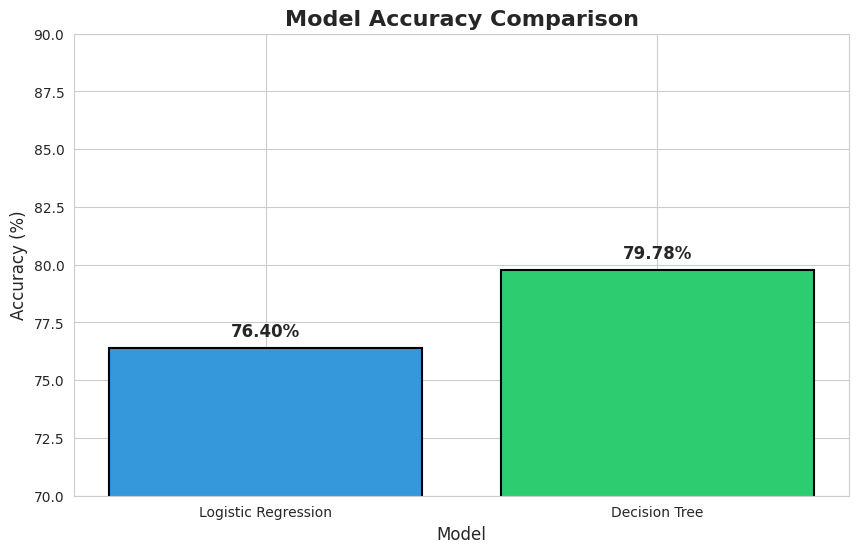

In [12]:
# Model comparison
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy (%)': [lr_accuracy*100, dt_accuracy*100]
})

print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(models_comparison.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(models_comparison['Model'], models_comparison['Accuracy (%)'],
        color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5)
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(70, 90)
for i, v in enumerate(models_comparison['Accuracy (%)']):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
plt.show()

In [13]:
print("\n" + "="*60)
print("KEY RESULTS")
print("="*60)
print(f"1. Overall survival rate: {train_df['Survived'].mean()*100:.2f}%")
print(f"2. Female survival rate: {gender_survival['female']*100:.2f}%")
print(f"3. Male survival rate: {gender_survival['male']*100:.2f}%")
print(f"4. Best performing model: {models_comparison.loc[models_comparison['Accuracy (%)'].idxmax(), 'Model']}")
print(f"5. Highest accuracy: {models_comparison['Accuracy (%)'].max():.2f}%")
print("\n✅ Analysis successfully completed!")


KEY RESULTS
1. Overall survival rate: 38.56%
2. Female survival rate: 74.20%
3. Male survival rate: 19.02%
4. Best performing model: Decision Tree
5. Highest accuracy: 79.78%

✅ Analysis successfully completed!


In [19]:
# 1. Split data for Conformal Prediction
# We divide the data into Training (to train the model),
# Calibration (to find the threshold), and Test (to evaluate performance)
X_train_cp, X_temp, y_train_cp, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test_cp, y_calib, y_test_cp = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Convert labels to numpy arrays to avoid indexing issues
y_calib_arr = y_calib.values
y_test_arr = y_test_cp.values

In [20]:
# 2. Train the underlying model
cp_model = DecisionTreeClassifier(max_depth=5, random_state=42)
cp_model.fit(X_train_cp, y_train_cp)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [21]:
# 3. CALIBRATION: Compute non-conformity scores
# Predict probabilities on the calibration set
calib_probs = cp_model.predict_proba(X_calib)
n_calib = len(y_calib_arr)

# Get the probability assigned to the true class for each sample
true_class_probs = calib_probs[np.arange(n_calib), y_calib_arr]

# Non-conformity score: 1 minus the probability of the true label
# Higher score means the model is more "surprised" or "uncomfortable"
scores = 1 - true_class_probs

In [22]:
# 4. QUANTILE: Calculate the confidence threshold (q-hat)
# For 90% confidence, we set alpha = 0.1
alpha = 0.1
q_level = np.ceil((n_calib + 1) * (1 - alpha)) / n_calib
qhat = np.quantile(scores, q_level, method='higher')


In [23]:
# 5. PREDICTION: Generate prediction sets for the test set
test_probs = cp_model.predict_proba(X_test_cp)

# Include all classes where (1 - class_probability) <= qhat
prediction_sets = (1 - test_probs <= qhat)

In [24]:
# 6. Results Analysis
cp_results = pd.DataFrame({
    'Actual': y_test_arr,
    'ML_Prediction': cp_model.predict(X_test_cp),
    'CP_Prediction_Set': [list(np.where(row)[0]) for row in prediction_sets]
})

# Calculate Empirical Coverage (The percentage of sets containing the true label)
coverage = np.mean([y_test_arr[i] in cp_results['CP_Prediction_Set'][i] for i in range(len(y_test_arr))])

print(f"✅ Conformal Prediction completed successfully!")
print(f"Confidence threshold (qhat): {qhat:.4f}")
print(f"Empirical coverage (Guaranteed >= 90%): {coverage:.2%}")

# Display first 10 results
cp_results.head(10)

✅ Conformal Prediction completed successfully!
Confidence threshold (qhat): 0.8571
Empirical coverage (Guaranteed >= 90%): 93.26%


,Actual,ML_Prediction,CP_Prediction_Set
0,0,0,"[0, 1]"
1,1,1,[1]
2,1,1,[1]
3,1,1,[1]
4,1,0,"[0, 1]"
5,0,0,"[0, 1]"
6,0,0,[0]
7,1,0,"[0, 1]"
8,0,1,"[0, 1]"
9,1,0,"[0, 1]"


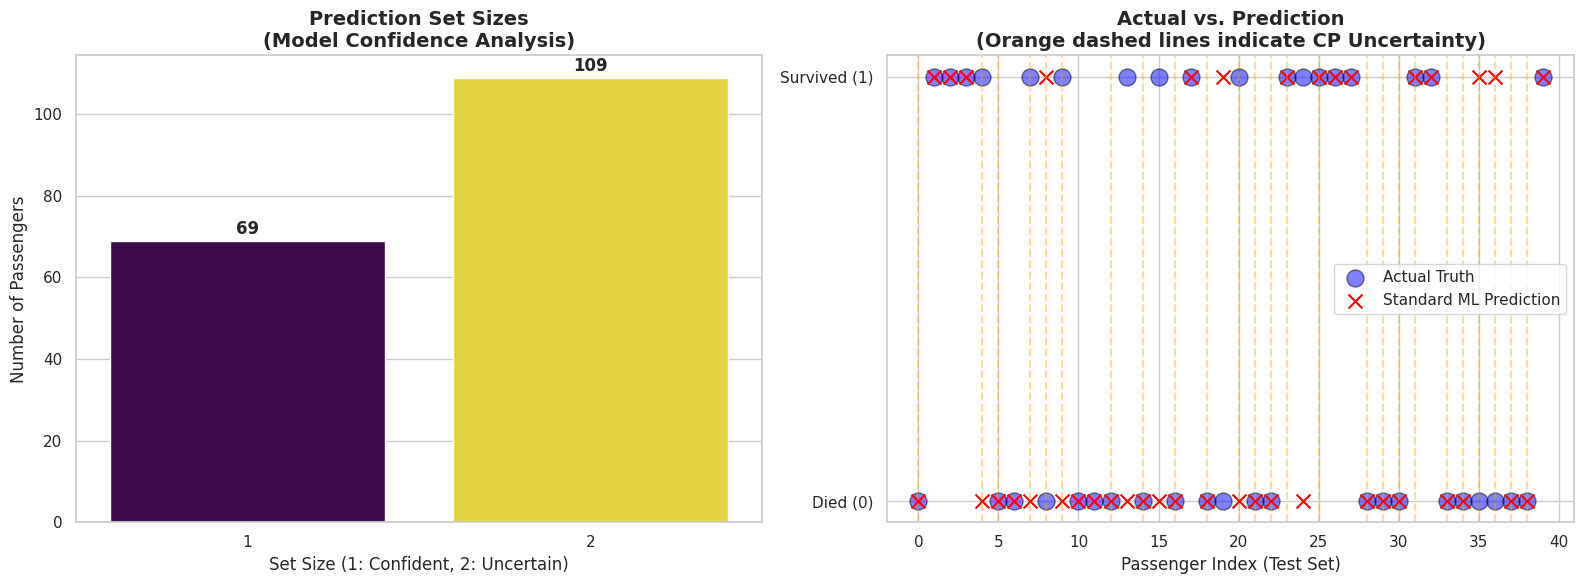

-------------------------------------------------------
CONFORMAL PREDICTION - FINAL PERFORMANCE REPORT
-------------------------------------------------------
Total Test Samples        : 178
Confident Predictions (1) : 69 (38.8%)
Uncertain Predictions (2) : 109 (61.2%)
Target Confidence Level   : 90.00%
Achieved Empirical Coverage: 93.26%
-------------------------------------------------------


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the size of each prediction set
# Set size 1 means the model is confident, size 2 means it is uncertain
cp_results['Set_Size'] = cp_results['CP_Prediction_Set'].apply(len)

# 2. Set up the visualization environment
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Distribution of Prediction Set Sizes
# This shows the frequency of confident vs. uncertain predictions
sns.countplot(x='Set_Size', data=cp_results, hue='Set_Size', palette='viridis', ax=ax1, legend=False)
ax1.set_title('Prediction Set Sizes\n(Model Confidence Analysis)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Set Size (1: Confident, 2: Uncertain)', fontsize=12)
ax1.set_ylabel('Number of Passengers', fontsize=12)

# Adding count labels on top of the bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

# Plot B: Visualizing Model Uncertainty (First 40 Samples)
# Comparing Actual Truth vs. Standard ML Prediction
subset = cp_results.head(40)
ax2.scatter(range(len(subset)), subset['Actual'], label='Actual Truth', alpha=0.5, s=150, color='blue', edgecolors='black')
ax2.scatter(range(len(subset)), subset['ML_Prediction'], label='Standard ML Prediction', marker='x', s=100, color='red')

# Adding vertical dashed lines to highlight uncertain cases ([0, 1] sets)
for i in range(len(subset)):
    if subset.iloc[i]['Set_Size'] == 2:
        ax2.axvline(x=i, color='orange', linestyle='--', alpha=0.4)

ax2.set_title('Actual vs. Prediction\n(Orange dashed lines indicate CP Uncertainty)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Passenger Index (Test Set)', fontsize=12)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Died (0)', 'Survived (1)'])
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

# 3. Final Summary Statistics in English
print("-" * 55)
print("CONFORMAL PREDICTION - FINAL PERFORMANCE REPORT")
print("-" * 55)
print(f"Total Test Samples        : {len(cp_results)}")
print(f"Confident Predictions (1) : {(cp_results['Set_Size']==1).sum()} ({(cp_results['Set_Size']==1).mean():.1%})")
print(f"Uncertain Predictions (2) : {(cp_results['Set_Size']==2).sum()} ({(cp_results['Set_Size']==2).mean():.1%})")
print(f"Target Confidence Level   : 90.00%")
print(f"Achieved Empirical Coverage: {coverage:.2%}")
print("-" * 55)